# Modeling and Evaluation Summary

This notebook documents the Stage 10-11 modeling track for the final S&P 500 volatility project. The primary task is regression because the target is continuous future 5-day realized volatility.

In [1]:
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


## Holdout metrics

The split is chronological. The naive baseline predicts that the most recent available five-day realized volatility persists into the next five trading days.

In [2]:
import pandas as pd
metrics = pd.read_csv('reports/tables/model_metrics.csv')
metrics

,model,MAE,RMSE,R2,MAE_improvement_vs_naive,RMSE_improvement_vs_naive
0,naive_last_5d_realized_vol,0.003855,0.006342,-0.175610,0.000000,0.000000
1,linear_regression,0.002775,0.004688,0.357503,0.280117,0.260729
2,ridge,0.002774,0.004688,0.357601,0.280322,0.260785
3,random_forest,0.003532,0.006555,-0.255827,0.083735,-0.033554


## Residual diagnostics

The residual figure includes residuals vs fitted values, histogram, QQ plot, and residuals over time. These checks support the discussion of linearity, heteroscedasticity, normality, and independence risks.

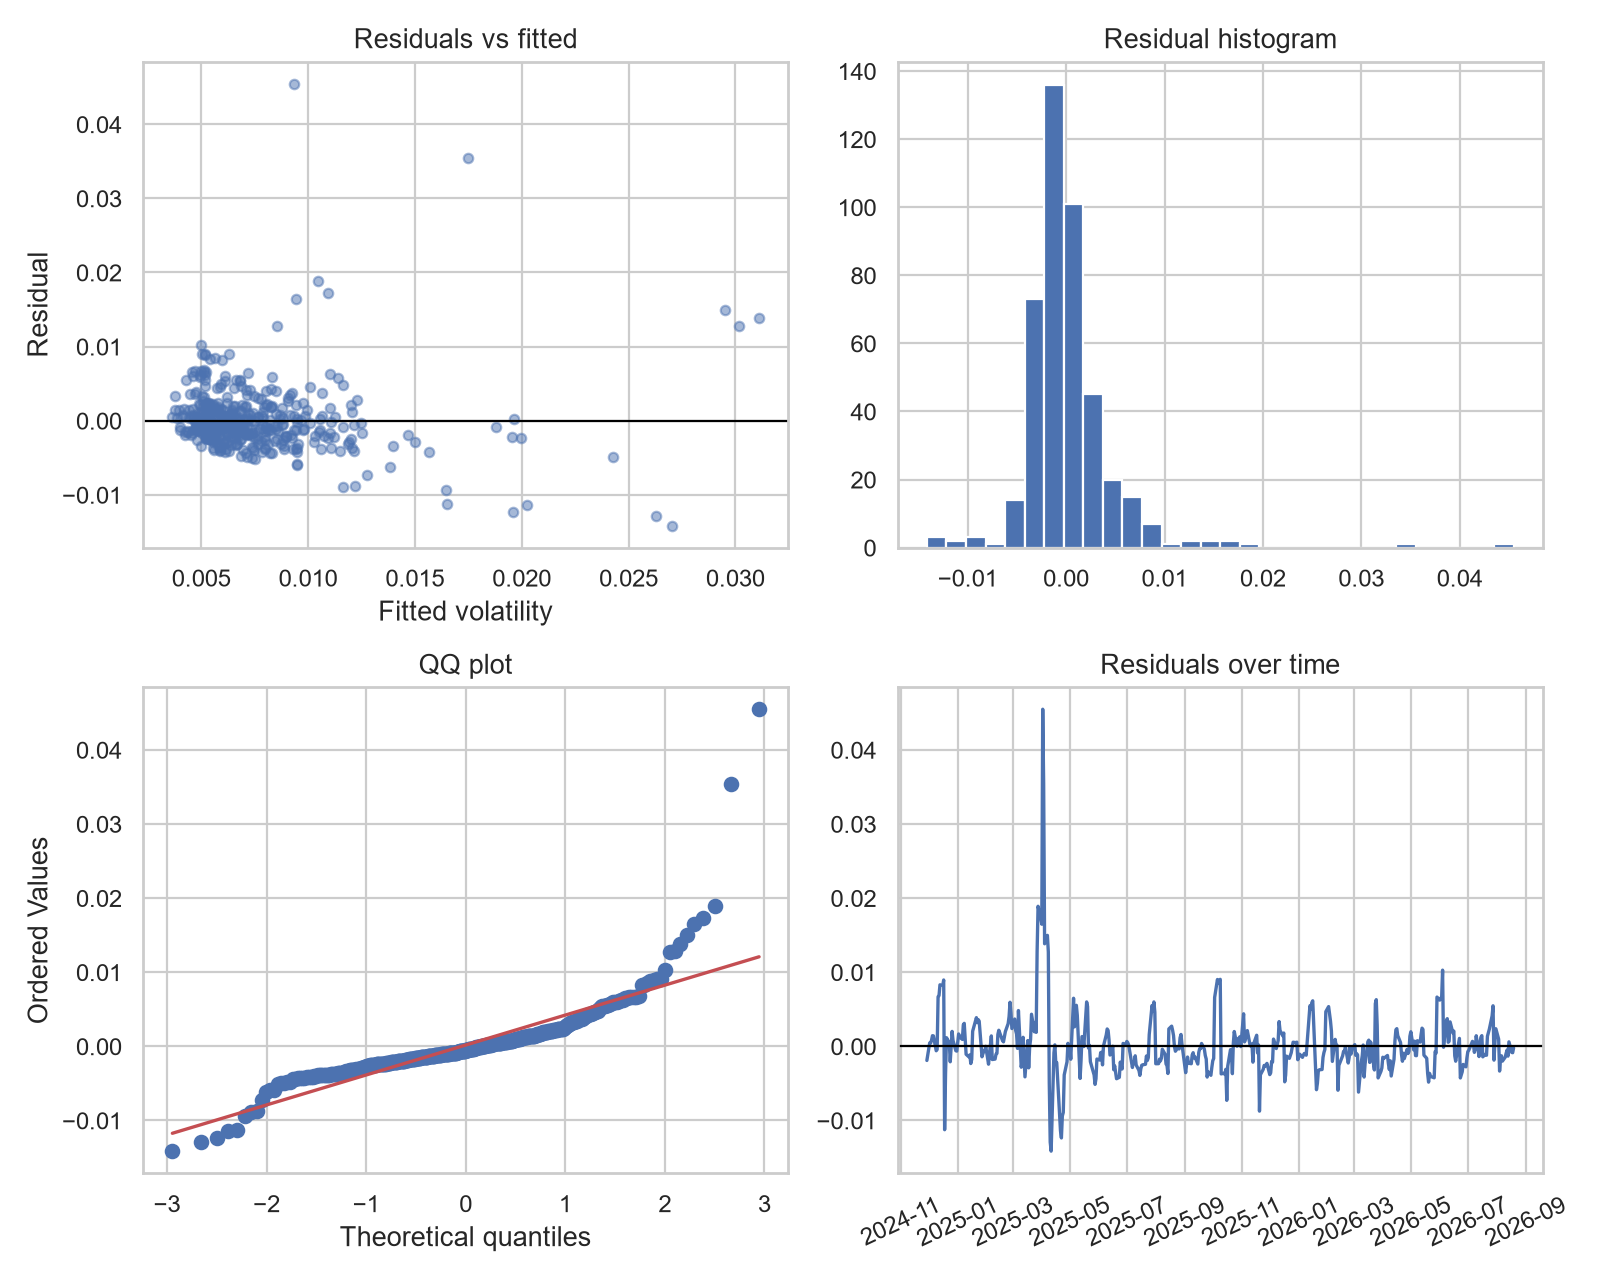

In [3]:
from IPython.display import Image, display
display(Image(filename='reports/figures/residual_diagnostics.png'))

## Scenario and uncertainty results

Performance is checked across all observations, normal-VIX observations, high-VIX observations, and high-realized-volatility observations. The bootstrap CI gives a practical uncertainty range for selected-model MAE.

In [4]:
scenario = pd.read_csv('reports/tables/scenario_metrics.csv')
ci = pd.read_csv('reports/tables/bootstrap_mae_ci.csv')
display(scenario)
display(ci)

,scenario,n,selected_MAE,naive_MAE,MAE_improvement_vs_naive,selected_bias
0,All test observations,430,0.002774,0.003855,0.280322,0.000168
1,Low/normal VIX regime,366,0.002446,0.003308,0.260649,0.000322
2,High VIX regime,64,0.004652,0.006982,0.333632,-0.000713
3,High realized-volatility regime,85,0.004098,0.007612,0.461593,-0.000876


,mae,bootstrap_mean,ci_lower,ci_upper,n_bootstrap
0,0.002774,0.002773,0.002426,0.003127,1000


## Interpretation

Ridge is selected because it slightly improves on Linear Regression in MAE/RMSE while retaining interpretability and regularization. Random Forest does not beat the naive baseline on RMSE, so the more complex model is not chosen. The model is useful for risk monitoring, but not for causal explanation or automated trading.